In [1]:
from mpi4py import MPI
import gmsh
import numpy as np
import time
from scipy.spatial import cKDTree
import pyvista as pv
from dolfinx import plot

eps_value = 5.0e-2

def exact_p_numpy_2d(points, eps=eps_value):
    points = np.asarray(points, dtype=np.float64)
    x = points[:, 0]
    y = points[:, 1]
    return x * (1.0 + y**2) * (np.tanh((x + y - 1.0) / eps) + 1.5)


def kappa_numpy(x):
    """kappa(x) = (tanh(10(x-0.5)) + 1.1)(x+0.5)(0.1 sin(20x) + 1)"""
    return (np.tanh(10.0 * (x - 0.5)) + 1.1) * (x + 0.5) * (0.1 * np.sin(20.0 * x) + 1.0)


def exact_q_numpy_2d(points, eps=eps_value):
    points = np.asarray(points, dtype=np.float64)
    x = points[:, 0]
    y = points[:, 1]
    a = 1.0 + y**2
    s = (x + y - 1.0) / eps
    tanh_s = np.tanh(s)
    sech2_s = 1.0 - tanh_s**2
    t = tanh_s + 1.5
    dpdx = a * (t + (x / eps) * sech2_s)
    dpdy = x * (2.0 * y * t + (a / eps) * sech2_s)
    kappa = kappa_numpy(x)
    values = np.zeros((points.shape[0], 2), dtype=np.float64)
    values[:, 0] = -kappa * dpdx
    values[:, 1] = -kappa * dpdy
    return values


Lx, Ly = 1.0, 1.0

In [2]:
from dolfinx import mesh, fem
import ufl
import numpy as np
from dolfinx.io import gmsh as gmshio
from mpi4py import MPI

# ---------------------------------------------------------------------
# 1. Mesh and tags (same mesh as reference)
# ---------------------------------------------------------------------
ref = 6
filename = f"regular_mesh_{ref}.msh"
msh, cell_markers, facet_markers = gmshio.read_from_msh(filename, MPI.COMM_WORLD, 0, gdim=2)[0:3]

tdim = msh.topology.dim  # 2
fdim = tdim - 1          # 1

lc = 1.0 / (2**ref)      # mesh size
h = lc

omega = msh

# ---------------------------------------------------------------------
# 2. Function space (standard CG on the bulk only)
# ---------------------------------------------------------------------
order = 1
V = fem.functionspace(omega, ("Lagrange", order))

# ---------------------------------------------------------------------
# 3. Trial / Test / Solution function
# ---------------------------------------------------------------------
phi = ufl.TestFunction(V)
p = fem.Function(V, name="p")
dp = ufl.TrialFunction(V)

# ---------------------------------------------------------------------
# 4. Coordinates and data
# ---------------------------------------------------------------------
x = ufl.SpatialCoordinate(omega)
eps = eps_value
p_exact_ufl = x[0] * (1.0 + x[1]**2) * (ufl.tanh((x[0] + x[1] - 1.0) / eps) + 1.5)
kappa_ufl = (ufl.tanh(10.0 * (x[0] - 0.5)) + 1.1) * (x[0] + 0.5) * (0.1 * ufl.sin(20.0 * x[0]) + 1.0)
sigma_exact_ufl = kappa_ufl * ufl.grad(p_exact_ufl)
f_m = -ufl.div(sigma_exact_ufl)

f = fem.Function(V)
f_func = fem.Function(V)
interp_points = V.element.interpolation_points
f_expr = fem.Expression(f_m, interp_points)
f_func.interpolate(f_expr)
f.interpolate(f_expr)
# create function
k_m = fem.Function(V, name="kappa")

def k_callable(x):
    vals = (np.tanh(10.0 * (x[0] - 0.5)) + 1.1) * (x[0] + 0.5) * (0.1 * np.sin(20.0 * x[0]) + 1.0)
    return vals[np.newaxis, :]

k_m.interpolate(k_callable)

dx = ufl.Measure("dx", domain=omega)

# compute domain bbox to locate sides
coords = omega.geometry.x
xx = coords[:, 0]
yy = coords[:, 1]
xmin, xmax = xx.min(), xx.max()
ymin, ymax = yy.min(), yy.max()

tol = 1e-10 * max(xmax - xmin, ymax - ymin)

# locate boundary facets for bottom (y = ymin) and top (y = ymax)
bottom_facets = mesh.locate_entities_boundary(
    omega, fdim, lambda x: np.isclose(x[1], ymin, atol=tol)
)
top_facets = mesh.locate_entities_boundary(
    omega, fdim, lambda x: np.isclose(x[1], ymax, atol=tol)
)

# create meshtags for those Neumann parts
indices = np.concatenate([bottom_facets, top_facets]).astype(np.int32)
values = np.concatenate([
    np.full(bottom_facets.shape, 10, dtype=np.int32),  # bottom tag = 10
    np.full(top_facets.shape,    20, dtype=np.int32),  # top tag    = 20
])
neumann_tags = mesh.meshtags(omega, fdim, indices, values)

dsN = ufl.Measure("ds", domain=omega, subdomain_data=neumann_tags)
n = ufl.FacetNormal(omega)
g_exact = ufl.dot(sigma_exact_ufl, n)

# ---------------------------------------------------------------------
# 5. Weak form (standard Darcy / Poisson form)
# ---------------------------------------------------------------------
a = ufl.inner(k_m * ufl.grad(dp), ufl.grad(phi)) * dx
L = f_m * phi * dx
L += g_exact * phi * dsN(10)
L += g_exact * phi * dsN(20)

A_form = ufl.inner(k_m * ufl.grad(dp), ufl.grad(phi)) * dx
b_form = L

# ---------------------------------------------------------------------
# 6. Dirichlet BCs (left/right)
# ---------------------------------------------------------------------
left_dofs   = fem.locate_dofs_geometrical(V, lambda x: np.isclose(x[0], xmin, atol=tol))
right_dofs  = fem.locate_dofs_geometrical(V, lambda x: np.isclose(x[0], xmax, atol=tol))
top_dofs    = fem.locate_dofs_geometrical(V, lambda x: np.isclose(x[1], ymax, atol=tol))
bottom_dofs = fem.locate_dofs_geometrical(V, lambda x: np.isclose(x[1], ymin, atol=tol))

all_dofs = np.unique(np.concatenate([left_dofs, right_dofs]))
dof_coords = V.tabulate_dof_coordinates()

p_bc_fun = fem.Function(V)
p_bc_fun.x.array[all_dofs] = exact_p_numpy_2d(dof_coords[all_dofs], eps=eps_value)

bc = fem.dirichletbc(p_bc_fun, all_dofs)
bcs = [bc]

# ---------------------------------------------------------------------
# 7. Solve linear problem using dolfinx.fem.petsc.LinearProblem
# ---------------------------------------------------------------------
from dolfinx.fem import petsc

linear_problem = petsc.LinearProblem(
    a=A_form,
    L=b_form,
    bcs=bcs,
    petsc_options={
        "ksp_type": "preonly",
        "pc_type": "lu",
        "pc_factor_mat_solver_type": "mumps",
        "ksp_error_if_not_converged": True,
    },
    petsc_options_prefix="pmix_"
)

cg_solve_start = time.perf_counter()
p_sol = linear_problem.solve()
cg_solve_time = omega.comm.allreduce(time.perf_counter() - cg_solve_start, op=MPI.MAX)
p_sol.name = "pressure"

p.x.array[:] = p_sol.x.array[:]

# ---------------------------------------------------------------------
# 8. Diagnostics
# ---------------------------------------------------------------------
print("DOFs in V:", V.dofmap.index_map.size_global)
print(f"CG solve time: {cg_solve_time:.6f} s")

Info    : Reading 'regular_mesh_6.msh'...
Info    : 36993 entities
Info    : 4225 nodes
Info    : 36993 elements
Info    : Done reading 'regular_mesh_6.msh'
DOFs in V: 4225
CG solve time: 2.077638 s


In [14]:
from dolfinx import io

with io.XDMFFile(omega.comm, "pressure.xdmf", "w") as xdmf:
    xdmf.write_mesh(omega)
    xdmf.write_function(p_sol)

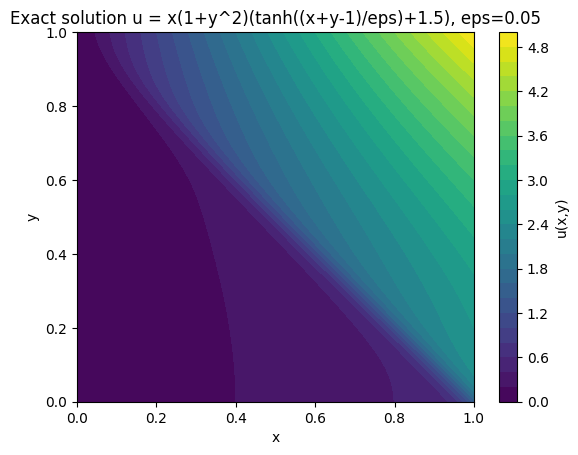

In [4]:
import numpy as np
import matplotlib.pyplot as plt

n = 100
x = np.linspace(0, 1, n)
y = np.linspace(0, 1, n)
X, Y = np.meshgrid(x, y)

U = exact_p_numpy_2d(np.column_stack([X.ravel(), Y.ravel()]), eps=eps_value).reshape(X.shape)

plt.figure()
plt.contourf(X, Y, U, levels=30)
plt.colorbar(label="u(x,y)")
plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Exact solution u = x(1+y^2)(tanh((x+y-1)/eps)+1.5), eps={eps_value}")
plt.show()

In [5]:
# ---------------------------------------------------------------------
# CG convergence analysis for p and q on ref = 2,3,4,5,6,7
# ---------------------------------------------------------------------
import basix
from dolfinx.fem import petsc
import math

def convergence_rate(errors, hs):
    rates = [None]
    for i in range(1, len(errors)):
        if errors[i - 1] > 0 and errors[i] > 0 and hs[i] != hs[i - 1]:
            rates.append(math.log(errors[i] / errors[i - 1]) / math.log(hs[i] / hs[i - 1]))
        else:
            rates.append(None)
    return rates


def exact_p_numpy_2d(points, eps=eps_value):
    points = np.asarray(points, dtype=np.float64)
    x = points[:, 0]
    y = points[:, 1]
    return x * (1.0 + y**2) * (np.tanh((x + y - 1.0) / eps) + 1.5)


def kappa_numpy(x):
    return (np.tanh(10.0 * (x - 0.5)) + 1.1) * (x + 0.5) * (0.1 * np.sin(20.0 * x) + 1.0)


def exact_q_numpy_2d(points, eps=eps_value):
    points = np.asarray(points, dtype=np.float64)
    x = points[:, 0]
    y = points[:, 1]
    a = 1.0 + y**2
    s = (x + y - 1.0) / eps
    tanh_s = np.tanh(s)
    sech2_s = 1.0 - tanh_s**2
    t = tanh_s + 1.5
    dpdx = a * (t + (x / eps) * sech2_s)
    dpdy = x * (2.0 * y * t + (a / eps) * sech2_s)
    kappa = kappa_numpy(x)
    values = np.zeros((points.shape[0], 2), dtype=np.float64)
    values[:, 0] = -kappa * dpdx
    values[:, 1] = -kappa * dpdy
    return values


def solve_cg_problem_for_ref(ref_value):
    filename = f"regular_mesh_{ref_value}.msh"
    msh, cell_markers, facet_markers = gmshio.read_from_msh(filename, MPI.COMM_WORLD, 0, gdim=2)[0:3]

    tdim_local = msh.topology.dim
    fdim_local = tdim_local - 1
    h_local = 1.0 / (2**ref_value)

    V_local = fem.functionspace(msh, ("Lagrange", order))
    phi_local = ufl.TestFunction(V_local)
    dp_local = ufl.TrialFunction(V_local)
    p_sol_local = fem.Function(V_local, name="pressure")

    x_local = ufl.SpatialCoordinate(msh)
    p_exact_local = x_local[0] * (1.0 + x_local[1]**2) * (ufl.tanh((x_local[0] + x_local[1] - 1.0) / eps_value) + 1.5)
    kappa_local = (ufl.tanh(10.0 * (x_local[0] - 0.5)) + 1.1) * (x_local[0] + 0.5) * (0.1 * ufl.sin(20.0 * x_local[0]) + 1.0)
    sigma_exact_local = kappa_local * ufl.grad(p_exact_local)
    f_m_local = -ufl.div(sigma_exact_local)

    f_func_local = fem.Function(V_local)
    interp_points_local = V_local.element.interpolation_points
    f_expr_local = fem.Expression(f_m_local, interp_points_local)
    f_func_local.interpolate(f_expr_local)

    k_m_local = fem.Function(V_local, name="kappa")

    def k_callable_local(x):
        vals = (np.tanh(10.0 * (x[0] - 0.5)) + 1.1) * (x[0] + 0.5) * (0.1 * np.sin(20.0 * x[0]) + 1.0)
        return vals[np.newaxis, :]

    k_m_local.interpolate(k_callable_local)

    coords_local = msh.geometry.x
    xx_local = coords_local[:, 0]
    yy_local = coords_local[:, 1]
    xmin_local, xmax_local = xx_local.min(), xx_local.max()
    ymin_local, ymax_local = yy_local.min(), yy_local.max()
    tol_local = 1e-10 * max(xmax_local - xmin_local, ymax_local - ymin_local)

    bottom_facets_local = mesh.locate_entities_boundary(
        msh, fdim_local, lambda x: np.isclose(x[1], ymin_local, atol=tol_local)
    )
    top_facets_local = mesh.locate_entities_boundary(
        msh, fdim_local, lambda x: np.isclose(x[1], ymax_local, atol=tol_local)
    )

    indices_local = np.concatenate([bottom_facets_local, top_facets_local]).astype(np.int32)
    values_local = np.concatenate([
        np.full(bottom_facets_local.shape, 10, dtype=np.int32),
        np.full(top_facets_local.shape, 20, dtype=np.int32),
    ])
    neumann_tags_local = mesh.meshtags(msh, fdim_local, indices_local, values_local)
    dsN_local = ufl.Measure("ds", domain=msh, subdomain_data=neumann_tags_local)
    n_local = ufl.FacetNormal(msh)
    g_exact_local = ufl.dot(sigma_exact_local, n_local)

    a_local = ufl.inner(k_m_local * ufl.grad(dp_local), ufl.grad(phi_local)) * ufl.dx
    L_local = f_m_local * phi_local * ufl.dx
    L_local += g_exact_local * phi_local * dsN_local(10)
    L_local += g_exact_local * phi_local * dsN_local(20)

    left_dofs_local = fem.locate_dofs_geometrical(V_local, lambda x: np.isclose(x[0], xmin_local, atol=tol_local))
    right_dofs_local = fem.locate_dofs_geometrical(V_local, lambda x: np.isclose(x[0], xmax_local, atol=tol_local))
    all_dofs_local = np.unique(np.concatenate([left_dofs_local, right_dofs_local]))
    dof_coords_local = V_local.tabulate_dof_coordinates()

    p_bc_fun_local = fem.Function(V_local)
    p_bc_fun_local.x.array[all_dofs_local] = exact_p_numpy_2d(dof_coords_local[all_dofs_local], eps=eps_value)
    bc_local = fem.dirichletbc(p_bc_fun_local, all_dofs_local)

    problem_local = petsc.LinearProblem(
        a=a_local,
        L=L_local,
        bcs=[bc_local],
        petsc_options={
            "ksp_type": "preonly",
            "pc_type": "lu",
            "pc_factor_mat_solver_type": "mumps",
            "ksp_error_if_not_converged": True,
        },
        petsc_options_prefix=f"pmix_ref_{ref_value}_",
    )

    p_sol_local = problem_local.solve()
    p_sol_local.name = "pressure"

    return {
        "ref": ref_value,
        "omega": msh,
        "V": V_local,
        "p_sol": p_sol_local,
        "k_m": k_m_local,
        "f_func": f_func_local,
        "h": h_local,
        "dofs": V_local.dofmap.index_map.size_global,
    }


def map_reference_points_to_physical_for_mesh(mesh_obj, X_ref):
    X_ref = np.asarray(X_ref, dtype=np.float64)
    tdim_local = mesh_obj.topology.dim
    num_cells_local = mesh_obj.topology.index_map(tdim_local).size_local
    gdim_local = mesh_obj.geometry.dim
    points = np.empty((num_cells_local, len(X_ref), gdim_local), dtype=np.float64)

    cmap = mesh_obj.geometry.cmap
    x_dofmap = mesh_obj.geometry.dofmap
    x_geo = mesh_obj.geometry.x

    for c in range(num_cells_local):
        coords = x_geo[x_dofmap[c]]
        x_phys = cmap.push_forward(X_ref, coords)
        points[c, :, :] = x_phys[:, :gdim_local]

    return points


def eval_cellwise_expression_on_mesh(mesh_obj, expr_ufl, X_ref, value_size):
    X_ref = np.asarray(X_ref, dtype=np.float64)
    tdim_local = mesh_obj.topology.dim
    num_cells_local = mesh_obj.topology.index_map(tdim_local).size_local
    cells_local = np.arange(num_cells_local, dtype=np.int32)
    expr = fem.Expression(expr_ufl, X_ref)
    values = np.asarray(expr.eval(mesh_obj, cells_local))
    return values.reshape(num_cells_local, len(X_ref), value_size)


def cell_jacobian_determinants_for_mesh(mesh_obj):
    tdim_local = mesh_obj.topology.dim
    mesh_obj.topology.create_connectivity(tdim_local, 0)
    ctv_local = mesh_obj.topology.connectivity(tdim_local, 0)
    num_cells_local = mesh_obj.topology.index_map(tdim_local).size_local
    omega_geometry_local = mesh_obj.geometry.x[:, :mesh_obj.geometry.dim]

    detJ = np.empty(num_cells_local, dtype=np.float64)
    for c in range(num_cells_local):
        verts = np.asarray(ctv_local.links(c), dtype=np.int64)
        coords = omega_geometry_local[verts]
        v1 = coords[1] - coords[0]
        v2 = coords[2] - coords[0]
        detJ[c] = abs(v1[0] * v2[1] - v1[1] * v2[0])

    return detJ


def compute_pressure_l2_error_on_mesh(cg_ctx, degree=5):
    X_ref, weights = basix.make_quadrature(basix.CellType.triangle, degree)
    detJ = cell_jacobian_determinants_for_mesh(cg_ctx["omega"])
    X_cell = map_reference_points_to_physical_for_mesh(cg_ctx["omega"], X_ref)
    X_flat = X_cell.reshape(-1, cg_ctx["omega"].geometry.dim)

    p_exact_cell = exact_p_numpy_2d(X_flat).reshape(len(detJ), len(X_ref))
    p_cg_cell = eval_cellwise_expression_on_mesh(cg_ctx["omega"], cg_ctx["p_sol"], X_ref, 1)[:, :, 0]

    sq = (p_cg_cell - p_exact_cell) ** 2
    err_sq_local = float(np.sum(detJ * (sq @ weights)))
    err_sq = cg_ctx["omega"].comm.allreduce(err_sq_local, op=MPI.SUM)
    return math.sqrt(err_sq)


def compute_q_cg_l2_error_on_mesh(cg_ctx, degree=5):
    X_ref, weights = basix.make_quadrature(basix.CellType.triangle, degree)
    detJ = cell_jacobian_determinants_for_mesh(cg_ctx["omega"])
    X_cell = map_reference_points_to_physical_for_mesh(cg_ctx["omega"], X_ref)
    X_flat = X_cell.reshape(-1, cg_ctx["omega"].geometry.dim)

    q_exact_cell = exact_q_numpy_2d(X_flat).reshape(len(detJ), len(X_ref), cg_ctx["omega"].geometry.dim)
    q_cg_ufl_local = -cg_ctx["k_m"] * ufl.grad(cg_ctx["p_sol"])
    q_cg_cell = eval_cellwise_expression_on_mesh(cg_ctx["omega"], q_cg_ufl_local, X_ref, cg_ctx["omega"].geometry.dim)

    sq = np.sum((q_cg_cell - q_exact_cell) ** 2, axis=2)
    err_sq_local = float(np.sum(detJ * (sq @ weights)))
    err_sq = cg_ctx["omega"].comm.allreduce(err_sq_local, op=MPI.SUM)
    return math.sqrt(err_sq)


cg_convergence_refs = [2, 3, 4, 5, 6, 7]
cg_convergence_results = []
cg_convergence_by_ref = {}

for ref_case in cg_convergence_refs:
    cg_ctx_case = solve_cg_problem_for_ref(ref_case)
    err_p_case = compute_pressure_l2_error_on_mesh(cg_ctx_case, degree=5)
    err_q_case = compute_q_cg_l2_error_on_mesh(cg_ctx_case, degree=5)

    cg_convergence_results.append(
        {
            "ref": ref_case,
            "h": cg_ctx_case["h"],
            "dofs": cg_ctx_case["dofs"],
            "p_L2": err_p_case,
            "q_L2": err_q_case,
        }
    )
    cg_convergence_by_ref[ref_case] = cg_convergence_results[-1]

p_errors_conv = [item["p_L2"] for item in cg_convergence_results]
q_errors_conv = [item["q_L2"] for item in cg_convergence_results]
hs_conv = [item["h"] for item in cg_convergence_results]
p_rates_conv = convergence_rate(p_errors_conv, hs_conv)
q_rates_conv = convergence_rate(q_errors_conv, hs_conv)

if MPI.COMM_WORLD.rank == 0:
    print(f"{'ref':>6} {'h':>12} {'DOFs':>10} {'||p_CG - p_exact||_L2':>24} {'rate(p)':>12} {'||q_CG - q_exact||_L2':>24} {'rate(q)':>12}")
    print("-" * 130)
    for i, item in enumerate(cg_convergence_results):
        rp = "---" if p_rates_conv[i] is None else f"{p_rates_conv[i]:.6f}"
        rq = "---" if q_rates_conv[i] is None else f"{q_rates_conv[i]:.6f}"
        print(
            f"{item['ref']:6d} {item['h']:12.6e} {item['dofs']:10d} {item['p_L2']:24.8e} {rp:>12} {item['q_L2']:24.8e} {rq:>12}"
        )

Info    : Reading 'regular_mesh_2.msh'...
Info    : 153 entities
Info    : 25 nodes
Info    : 153 elements
Info    : Done reading 'regular_mesh_2.msh'
Info    : Reading 'regular_mesh_3.msh'...
Info    : 593 entities
Info    : 81 nodes
Info    : 593 elements
Info    : Done reading 'regular_mesh_3.msh'
Info    : Reading 'regular_mesh_4.msh'...
Info    : 2337 entities
Info    : 289 nodes
Info    : 2337 elements
Info    : Done reading 'regular_mesh_4.msh'
Info    : Reading 'regular_mesh_5.msh'...
Info    : 9281 entities
Info    : 1089 nodes
Info    : 9281 elements
Info    : Done reading 'regular_mesh_5.msh'
Info    : Reading 'regular_mesh_6.msh'...
Info    : 36993 entities
Info    : 4225 nodes
Info    : 36993 elements
Info    : Done reading 'regular_mesh_6.msh'
Info    : Reading 'regular_mesh_7.msh'...
Info    : 147713 entities
Info    : 16641 nodes
Info    : 147713 elements
Info    : Done reading 'regular_mesh_7.msh'                                                                      
  

In [6]:
import math
from numpy.polynomial.legendre import leggauss

import basix
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from tqdm import tqdm

# ---------------------------------------------------------------------
# Direct q_rec workflow configuration
# ---------------------------------------------------------------------
# Increase this to sample more CG-flux data points on every element edge.
boundary_points_per_edge = 3

# These quadrature knobs are only for evaluation, not training.
conservation_points_per_edge = 6
source_quadrature_degree = 4
l2_quadrature_degree = 5

# Training parameter
max_epochs = 5000
learning_rate = 1.0e-3
batch_data_size = 8192
batch_strong_size = 4096
W_data = 1.0
W_strong = 0.1
W_reg = 1.0e-8

np.random.seed(7)
torch.manual_seed(7)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tdim = omega.topology.dim
gdim = omega.geometry.dim
if tdim != 2 or gdim != 2:
    raise NotImplementedError("This direct q_rec notebook section currently expects a 2D triangular mesh.")

omega.topology.create_connectivity(tdim, 0)
ctv = omega.topology.connectivity(tdim, 0)
num_cells = omega.topology.index_map(tdim).size_local
cells = np.arange(num_cells, dtype=np.int32)
cell_vertices = [np.asarray(ctv.links(c), dtype=np.int64) for c in range(num_cells)]
omega_geometry = omega.geometry.x[:, :gdim]


def reference_triangle_boundary_points(points_per_edge: int):
    """Reference edge samples for a triangle, excluding vertices to avoid duplicate corner data."""
    if points_per_edge < 1:
        raise ValueError("points_per_edge must be at least 1")

    s = (np.arange(points_per_edge, dtype=np.float64) + 0.5) / points_per_edge

    edge_01 = np.column_stack([s, np.zeros_like(s)])
    edge_12 = np.column_stack([1.0 - s, s])
    edge_20 = np.column_stack([np.zeros_like(s), 1.0 - s])

    X_ref = np.vstack([edge_01, edge_12, edge_20])
    edge_ids = np.repeat(np.arange(3, dtype=np.int32), points_per_edge)
    return X_ref, edge_ids


def reference_triangle_centroid():
    return np.array([[1.0 / 3.0, 1.0 / 3.0]], dtype=np.float64)


def map_reference_points_to_physical(X_ref):
    """Map reference points to physical points for every local cell."""
    X_ref = np.asarray(X_ref, dtype=np.float64)
    points = np.empty((num_cells, len(X_ref), gdim), dtype=np.float64)

    cmap = omega.geometry.cmap
    x_dofmap = omega.geometry.dofmap
    x_geo = omega.geometry.x

    for c in range(num_cells):
        coords = x_geo[x_dofmap[c]]
        x_phys = cmap.push_forward(X_ref, coords)
        points[c, :, :] = x_phys[:, :gdim]

    return points


def eval_cellwise_expression(expr_ufl, X_ref, value_size):
    """Evaluate a UFL expression cellwise at reference points."""
    X_ref = np.asarray(X_ref, dtype=np.float64)
    expr = fem.Expression(expr_ufl, X_ref)
    values = np.asarray(expr.eval(omega, cells))
    return values.reshape(num_cells, len(X_ref), value_size)


def cell_jacobian_determinants():
    """Affine triangle |det(J)| per cell, where reference weights sum to 1/2."""
    detJ = np.empty(num_cells, dtype=np.float64)
    for c, verts in enumerate(cell_vertices):
        coords = omega_geometry[verts]
        v1 = coords[1] - coords[0]
        v2 = coords[2] - coords[0]
        detJ[c] = abs(v1[0] * v2[1] - v1[1] * v2[0])
    return detJ


def cell_edge_normals_and_lengths():
    """Outward normals and lengths for the local edges (0,1), (1,2), (2,0)."""
    edge_pairs = [(0, 1), (1, 2), (2, 0)]
    normals = np.empty((num_cells, 3, gdim), dtype=np.float64)
    lengths = np.empty((num_cells, 3), dtype=np.float64)

    for c, verts in enumerate(cell_vertices):
        coords = omega_geometry[verts]
        centroid = coords.mean(axis=0)

        for edge_id, (i0, i1) in enumerate(edge_pairs):
            x0 = coords[i0]
            x1 = coords[i1]
            tangent = x1 - x0
            length = np.linalg.norm(tangent)
            normal = np.array([tangent[1], -tangent[0]], dtype=np.float64) / length

            midpoint = 0.5 * (x0 + x1)
            if np.dot(normal, centroid - midpoint) > 0.0:
                normal = -normal

            normals[c, edge_id, :] = normal
            lengths[c, edge_id] = length

    return normals, lengths


In [7]:
# ---------------------------------------------------------------------
# Extract cellwise CG-flux data on element boundaries plus centroids
# ---------------------------------------------------------------------
flux_collection_start = time.perf_counter()
q_cg_ufl = -k_m * ufl.grad(p_sol)

X_ref_boundary, boundary_edge_ids = reference_triangle_boundary_points(boundary_points_per_edge)
X_ref_centroid = reference_triangle_centroid()
X_ref_data = np.vstack([X_ref_boundary, X_ref_centroid])

X_data_cell = map_reference_points_to_physical(X_ref_data)
q_cg_data_cell = eval_cellwise_expression(q_cg_ufl, X_ref_data, gdim)

X_data = X_data_cell.reshape(-1, gdim)
q_cg_data = q_cg_data_cell.reshape(-1, gdim)

# Strong-form samples use cell centroids by default.
X_ref_strong = X_ref_centroid
X_strong_cell = map_reference_points_to_physical(X_ref_strong)
f_strong_cell = eval_cellwise_expression(f_func, X_ref_strong, 1)

X_strong = X_strong_cell.reshape(-1, gdim)
f_strong = f_strong_cell.reshape(-1)
flux_collection_time = omega.comm.allreduce(time.perf_counter() - flux_collection_start, op=MPI.MAX)

# Normalization statistics (computed once, reused in training and prediction)
x_mean_np = X_data.mean(axis=0)                              # shape (2,)
x_std_np  = X_data.std(axis=0) + 1e-12                      # shape (2,)
q_mean_np = q_cg_data.mean(axis=0, keepdims=True)           # shape (1, 2)
q_std_np  = q_cg_data.std(axis=0,  keepdims=True) + 1e-12  # shape (1, 2)
f_std_np  = float(f_strong.std()) + 1e-12                   # scalar

print(f"CG flux data points: {X_data.shape[0]:,}")
print(f"Strong-form points: {X_strong.shape[0]:,}")
print(f"Boundary points per edge: {boundary_points_per_edge}")
print(f"CG flux collection time: {flux_collection_time:.6f} s")
print(f"x mean: {x_mean_np},  std: {x_std_np}")
print(f"q_cg mean: {q_mean_np.ravel()},  std: {q_std_np.ravel()}")
print(f"f_strong std: {f_std_np:.4e}")

CG flux data points: 81,920
Strong-form points: 8,192
Boundary points per edge: 3
CG flux collection time: 0.115017 s
x mean: [0.5 0.5],  std: [0.28869158 0.28869158]
q_cg mean: [-5.75953223 -4.38310859],  std: [8.55777668 7.70611411]
f_strong std: 2.4168e+02


In [8]:
# ---------------------------------------------------------------------
# Train a direct vector neural network q_rec(x)
# ---------------------------------------------------------------------
class DirectFluxNet(nn.Module):
    def __init__(self, x_mean, x_std, in_dim=2, out_dim=2, hidden_dim=64, depth=4):
        super().__init__()
        self.register_buffer("x_mean", torch.as_tensor(x_mean, dtype=torch.float32))
        self.register_buffer("x_std",  torch.as_tensor(x_std,  dtype=torch.float32))

        layers = []
        last_dim = in_dim
        for _ in range(depth):
            layer = nn.Linear(last_dim, hidden_dim)
            nn.init.xavier_uniform_(layer.weight)
            nn.init.zeros_(layer.bias)
            layers.extend([layer, nn.Tanh()])
            last_dim = hidden_dim

        out = nn.Linear(last_dim, out_dim)
        nn.init.xavier_uniform_(out.weight)
        nn.init.zeros_(out.bias)
        layers.append(out)
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        x_scaled = (x - self.x_mean) / self.x_std  # z-score normalisation
        return self.net(x_scaled)


def train_q_rec_network(net, X_data, q_data, X_strong, f_strong, q_mean, q_std, f_std):
    X_data_t   = torch.as_tensor(X_data,   dtype=torch.float32, device=device)
    q_data_t   = torch.as_tensor(q_data,   dtype=torch.float32, device=device)
    X_strong_t = torch.as_tensor(X_strong, dtype=torch.float32, device=device)
    f_strong_t = torch.as_tensor(f_strong, dtype=torch.float32, device=device)
    q_mean_t   = torch.as_tensor(q_mean,   dtype=torch.float32, device=device)  # (1, 2)
    q_std_t    = torch.as_tensor(q_std,    dtype=torch.float32, device=device)  # (1, 2)

    # Normalize targets once: net learns q_norm = (q - q_mean) / q_std
    q_data_norm_t = (q_data_t - q_mean_t) / q_std_t

    optimizer = torch.optim.Adam(net.parameters(), lr=learning_rate, weight_decay=W_reg)
    history = {"epoch": [], "total": [], "data": [], "strong": []}

    best_loss = float("inf")
    best_state = None

    n_data       = X_data_t.shape[0]
    n_strong     = X_strong_t.shape[0]
    data_batch   = min(batch_data_size, n_data)
    strong_batch = min(batch_strong_size, n_strong)

    for epoch in tqdm(range(max_epochs)):
        optimizer.zero_grad()

        data_idx   = torch.randint(0, n_data,   (data_batch,),   device=device)
        strong_idx = torch.randint(0, n_strong, (strong_batch,), device=device)

        Xd      = X_data_t[data_idx]
        qd_norm = q_data_norm_t[data_idx]
        Xs      = X_strong_t[strong_idx].detach().clone().requires_grad_(True)
        fs      = f_strong_t[strong_idx]

        # Data loss: MSE on normalised targets — O(1) by construction
        q_pred_norm = net(Xd)
        data_loss   = torch.mean((q_pred_norm - qd_norm) ** 2)

        # Strong-form loss: div(q_phys) = sum_i q_std[i] * d(q_norm[i])/dx_i
        # (q_mean is constant so its divergence vanishes; chain rule through un-normalisation)
        q_norm_s = net(Xs)
        div_q = torch.zeros(Xs.shape[0], dtype=Xs.dtype, device=Xs.device)
        for comp in range(q_norm_s.shape[1]):
            grad_comp = torch.autograd.grad(
                q_norm_s[:, comp].sum(), Xs, create_graph=True, retain_graph=True,
            )[0]
            div_q = div_q + q_std_t[0, comp] * grad_comp[:, comp]
        # Normalise by f_std so both losses stay O(1) and W_strong keeps its meaning
        strong_loss = torch.mean(((div_q - fs) / f_std) ** 2)

        total_loss = W_data * data_loss + W_strong * strong_loss
        total_loss.backward()
        optimizer.step()

        value = float(total_loss.detach().cpu())
        if value < best_loss:
            best_loss  = value
            best_state = {k: v.detach().cpu().clone() for k, v in net.state_dict().items()}

        if epoch % 25 == 0 or epoch == max_epochs - 1:
            history["epoch"].append(epoch)
            history["total"].append(value)
            history["data"].append(float(data_loss.detach().cpu()))
            history["strong"].append(float(strong_loss.detach().cpu()))

    net.load_state_dict(best_state)
    return history


pinn_reconstruction_start = time.perf_counter()
q_rec_net = DirectFluxNet(
    x_mean=x_mean_np,
    x_std=x_std_np,
    in_dim=gdim,
    out_dim=gdim,
    hidden_dim=64,
    depth=4,
).to(device)

train_history = train_q_rec_network(
    q_rec_net, X_data, q_cg_data, X_strong, f_strong,
    q_mean_np, q_std_np, f_std_np,
)
pinn_reconstruction_time = omega.comm.allreduce(time.perf_counter() - pinn_reconstruction_start, op=MPI.MAX)
hybrid_total_time = cg_solve_time + flux_collection_time + pinn_reconstruction_time
hybrid_timings = {
    "cg_solve": cg_solve_time,
    "flux_collection": flux_collection_time,
    "pinn_reconstruction": pinn_reconstruction_time,
    "total_hybrid": hybrid_total_time,
}
print(f"PINN reconstruction training time: {pinn_reconstruction_time:.6f} s")
print(f"Total hybrid time (CG + flux collection + PINN): {hybrid_total_time:.6f} s")

100%|██████████| 5000/5000 [03:08<00:00, 26.49it/s]

PINN reconstruction training time: 185.318328 s
Total hybrid time (CG + flux collection + PINN): 187.510983 s


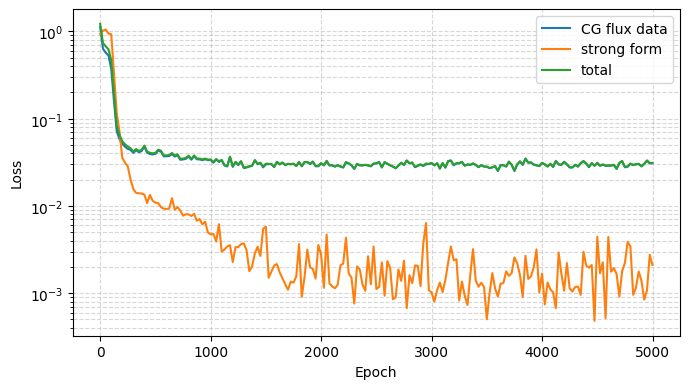

In [9]:
plt.figure(figsize=(7, 4))
plt.plot(train_history["epoch"], train_history["data"], label="CG flux data")
plt.plot(train_history["epoch"], train_history["strong"], label="strong form")
plt.plot(train_history["epoch"], train_history["total"], label="total")
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


CG LCE stats: {'max_abs': 0.21309900396070178, 'mean_abs': 0.00923904180269829, 'rms': 0.029496320039664126}
q_rec LCE stats: {'max_abs': 0.018462784268952814, 'mean_abs': 0.0004928053462832677, 'rms': 0.0014493331366774848}


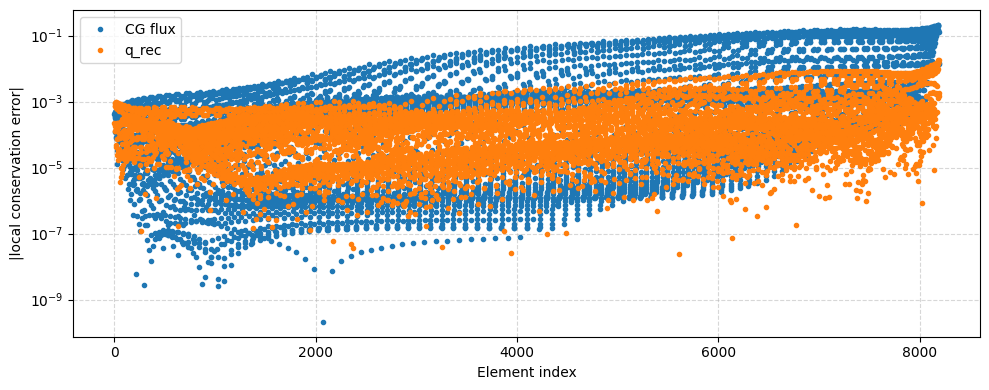

In [10]:
# ---------------------------------------------------------------------
# Local conservation before/after direct q_rec training
# ---------------------------------------------------------------------
def reference_triangle_edge_quadrature(points_per_edge: int):
    if points_per_edge < 1:
        raise ValueError("points_per_edge must be at least 1")

    s, w = leggauss(points_per_edge)
    s = 0.5 * (s + 1.0)
    w = 0.5 * w

    edge_01 = np.column_stack([s, np.zeros_like(s)])
    edge_12 = np.column_stack([1.0 - s, s])
    edge_20 = np.column_stack([np.zeros_like(s), 1.0 - s])

    X_ref = np.vstack([edge_01, edge_12, edge_20])
    edge_ids = np.repeat(np.arange(3, dtype=np.int32), points_per_edge)
    weights = np.tile(w, 3)
    return X_ref, edge_ids, weights


def predict_q_rec_numpy(points, batch_size=65536):
    points_t = torch.as_tensor(points, dtype=torch.float32, device=device)
    q_mean_t = torch.as_tensor(q_mean_np, dtype=torch.float32, device=device)
    q_std_t  = torch.as_tensor(q_std_np,  dtype=torch.float32, device=device)
    chunks = []
    q_rec_net.eval()
    with torch.no_grad():
        for start in range(0, points_t.shape[0], batch_size):
            pred_norm = q_rec_net(points_t[start:start + batch_size])
            pred = pred_norm * q_std_t + q_mean_t  # un-normalise to physical q
            chunks.append(pred.detach().cpu().numpy())
    return np.vstack(chunks)


def integrate_source_per_cell(degree=4):
    X_ref, weights = basix.make_quadrature(basix.CellType.triangle, degree)
    f_vals = eval_cellwise_expression(f_func, X_ref, 1)[:, :, 0]
    detJ = cell_jacobian_determinants()
    return detJ * (f_vals @ weights)


def integrate_boundary_flux_per_cell(q_values, edge_ids, edge_weights, normals, lengths):
    flux_integral = np.zeros(num_cells, dtype=np.float64)

    for edge_id in range(3):
        mask = edge_ids == edge_id
        q_edge = q_values[:, mask, :]
        normal_edge = normals[:, edge_id, :]
        dot_values = np.einsum("cqg,cg->cq", q_edge, normal_edge)
        flux_integral += lengths[:, edge_id] * (dot_values @ edge_weights[mask])

    return flux_integral


def compute_local_conservation_errors(points_per_edge=6, source_degree=4):
    X_ref_edge, edge_ids, edge_weights = reference_triangle_edge_quadrature(points_per_edge)

    normals, lengths = cell_edge_normals_and_lengths()
    int_f = integrate_source_per_cell(source_degree)

    q_cg_edge = eval_cellwise_expression(q_cg_ufl, X_ref_edge, gdim)
    int_q_cg = integrate_boundary_flux_per_cell(q_cg_edge, edge_ids, edge_weights, normals, lengths)

    X_edge_cell = map_reference_points_to_physical(X_ref_edge)
    q_rec_edge = predict_q_rec_numpy(X_edge_cell.reshape(-1, gdim)).reshape(num_cells, len(X_ref_edge), gdim)
    int_q_rec = integrate_boundary_flux_per_cell(q_rec_edge, edge_ids, edge_weights, normals, lengths)

    return {
        "lce_cg": int_q_cg - int_f,
        "lce_rec": int_q_rec - int_f,
        "int_q_cg": int_q_cg,
        "int_q_rec": int_q_rec,
        "int_f": int_f,
    }


def lce_stats(values):
    values = np.asarray(values, dtype=np.float64)
    return {
        "max_abs": float(np.max(np.abs(values))),
        "mean_abs": float(np.mean(np.abs(values))),
        "rms": float(np.sqrt(np.mean(values ** 2))),
    }


lce_results = compute_local_conservation_errors(
    points_per_edge=conservation_points_per_edge,
    source_degree=source_quadrature_degree,
)

cg_lce_stats = lce_stats(lce_results["lce_cg"])
q_rec_lce_stats = lce_stats(lce_results["lce_rec"])
print("CG LCE stats:", cg_lce_stats)
print("q_rec LCE stats:", q_rec_lce_stats)

plt.figure(figsize=(10, 4))
plt.plot(np.abs(lce_results["lce_cg"]), ".", label="CG flux")
plt.plot(np.abs(lce_results["lce_rec"]), ".", label="q_rec")
plt.yscale("log")
plt.xlabel("Element index")
plt.ylabel("|local conservation error|")
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
# ---------------------------------------------------------------------
# Flux L2 error against the manufactured exact flux
# ---------------------------------------------------------------------
def q_exact_numpy(points):
    return exact_q_numpy_2d(points, eps=eps_value)


def compute_flux_l2_errors(degree=5):
    X_ref, weights = basix.make_quadrature(basix.CellType.triangle, degree)
    detJ = cell_jacobian_determinants()

    X_cell = map_reference_points_to_physical(X_ref)
    X_flat = X_cell.reshape(-1, gdim)

    q_exact_cell = q_exact_numpy(X_flat).reshape(num_cells, len(X_ref), gdim)
    q_cg_cell = eval_cellwise_expression(q_cg_ufl, X_ref, gdim)
    q_rec_cell = predict_q_rec_numpy(X_flat).reshape(num_cells, len(X_ref), gdim)

    cg_sq = np.sum((q_cg_cell - q_exact_cell) ** 2, axis=2)
    rec_sq = np.sum((q_rec_cell - q_exact_cell) ** 2, axis=2)

    err_cg_sq_local = float(np.sum(detJ * (cg_sq @ weights)))
    err_rec_sq_local = float(np.sum(detJ * (rec_sq @ weights)))
    err_cg_sq = omega.comm.allreduce(err_cg_sq_local, op=MPI.SUM)
    err_rec_sq = omega.comm.allreduce(err_rec_sq_local, op=MPI.SUM)
    err_cg = math.sqrt(err_cg_sq)
    err_rec = math.sqrt(err_rec_sq)

    return {"q_cg_L2": err_cg, "q_rec_L2": err_rec}


l2_errors = compute_flux_l2_errors(degree=l2_quadrature_degree)
print("Flux L2 error before correction (CG):", l2_errors["q_cg_L2"])
print("Flux L2 error after correction (direct q_rec):", l2_errors["q_rec_L2"])
print("Improvement factor q_CG/q_rec:", l2_errors["q_cg_L2"] / l2_errors["q_rec_L2"])


Flux L2 error before correction (CG): 1.8469874846086238
Flux L2 error after correction (direct q_rec): 0.6025566656246782
Improvement factor q_CG/q_rec: 3.0652511041328006


In [12]:
# ---------------------------------------------------------------------
# Summary
# ---------------------------------------------------------------------
current_cg_context = {
    "ref": ref,
    "omega": omega,
    "V": V,
    "p_sol": p_sol,
    "k_m": k_m,
    "f_func": f_func,
    "h": h,
    "dofs": V.dofmap.index_map.size_global,
}

current_p_cg_l2 = compute_pressure_l2_error_on_mesh(current_cg_context, degree=l2_quadrature_degree)

if MPI.COMM_WORLD.rank == 0:
    print("=" * 72)
    print(f"  2D q_rec PINN + CG — complex kappa, tanh exact, ref={ref}, eps={eps_value}")
    print("=" * 72)
    print(f"  kappa = (tanh(10(x-0.5))+1.1)(x+0.5)(0.1 sin(20x)+1)")
    print(f"  h                      = {h:.6e}")
    print(f"  DOFs in V              = {V.dofmap.index_map.size_global}")
    print(f"  CG flux data points    = {X_data.shape[0]:,}")
    print(f"  Strong-form points     = {X_strong.shape[0]:,}")
    print(f"  Boundary pts / edge    = {boundary_points_per_edge}")
    print(f"  CG solve time          = {hybrid_timings['cg_solve']:.6f} s")
    print(f"  CG flux collect time   = {hybrid_timings['flux_collection']:.6f} s")
    print(f"  q_rec PINN time        = {hybrid_timings['pinn_reconstruction']:.6f} s")
    print(f"  Total hybrid time      = {hybrid_timings['total_hybrid']:.6f} s")
    print(f"  ||p_CG - p_exact||_L2  = {current_p_cg_l2:.6e}")
    print(f"  ||q_CG - q_exact||_L2  = {l2_errors['q_cg_L2']:.6e}")
    print(f"  ||q_rec - q_exact||_L2 = {l2_errors['q_rec_L2']:.6e}")
    print(f"  q_CG / q_rec improve   = {l2_errors['q_cg_L2'] / l2_errors['q_rec_L2']:.6f}")
    print(f"  max  |R_i| CG          = {cg_lce_stats['max_abs']:.6e}")
    print(f"  max  |R_i| q_rec       = {q_rec_lce_stats['max_abs']:.6e}")
    print(f"  mean |R_i| CG          = {cg_lce_stats['mean_abs']:.6e}")
    print(f"  mean |R_i| q_rec       = {q_rec_lce_stats['mean_abs']:.6e}")
    print("=" * 72)

  2D q_rec PINN + CG — complex kappa, tanh exact, ref=6, eps=0.05
  kappa = (tanh(10(x-0.5))+1.1)(x+0.5)(0.1 sin(20x)+1)
  h                      = 1.562500e-02
  DOFs in V              = 4225
  CG flux data points    = 81,920
  Strong-form points     = 8,192
  Boundary pts / edge    = 3
  CG solve time          = 2.077638 s
  CG flux collect time   = 0.115017 s
  q_rec PINN time        = 185.318328 s
  Total hybrid time      = 187.510983 s
  ||p_CG - p_exact||_L2  = 5.838528e-03
  ||q_CG - q_exact||_L2  = 1.846987e+00
  ||q_rec - q_exact||_L2 = 6.025567e-01
  q_CG / q_rec improve   = 3.065251
  max  |R_i| CG          = 2.130990e-01
  max  |R_i| q_rec       = 1.846278e-02
  mean |R_i| CG          = 9.239042e-03
  mean |R_i| q_rec       = 4.928053e-04


In [13]:
# Run the summary cell above to generate fresh tanh-case diagnostics for the current eps_value.